In [1]:
import copy

import matplotlib.pyplot as plt
import pandas as pd
import torch
from matplotlib.patches import Rectangle
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import Swin_T_Weights, alexnet, resnet18, swin_t
from torchvision.transforms import v2

In [2]:
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda:0")

PyTorch: 2.11.0+cu128
CUDA: 12.8
Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
features = 28 * 28
classes = 10

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

train_dataset = datasets.FashionMNIST(
    root="../../src/data",
    train=True,
    download=True,
    transform=transform,
)
train_size, val_size = (
    int(len(train_dataset) * 0.9),
    int(len(train_dataset) - len(train_dataset) * 0.9),
)
train_dataset_s, val_dataset_s = random_split(
    train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

test_dataset = datasets.FashionMNIST(
    root="../../src/data",
    train=False,
    download=True,
    transform=transform,
)

batch_size = 128

train_loader = DataLoader(
    train_dataset_s, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset_s, batch_size=batch_size, shuffle=False, drop_last=False
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, drop_last=False
)

# EDA

In [34]:
print("data size: ")
(
    train_dataset.data.shape,
    train_dataset.targets.shape,
    test_dataset.data.shape,
    test_dataset.targets.shape,
)

data size: 


(torch.Size([60000, 28, 28]),
 torch.Size([60000]),
 torch.Size([10000, 28, 28]),
 torch.Size([10000]))

In [35]:
print(
    "data dtype: data - uint8 is [0, 255] only int , targets - int64 is [-2^63 ... 2^63 - 1] only int. So no nan or inf vales"
)
print("Because it doesn't support NaN or Inf values")
(
    train_dataset.data.dtype,
    train_dataset.targets.dtype,
    test_dataset.data.dtype,
    test_dataset.targets.dtype,
)

data dtype: data - uint8 is [0, 255] only int , targets - int64 is [-2^63 ... 2^63 - 1] only int. So no nan or inf vales
Because it doesn't support NaN or Inf values


(torch.uint8, torch.int64, torch.uint8, torch.int64)

In [36]:
print("targets min and max: ")
train_dataset.targets.min(), test_dataset.targets.max()

targets min and max: 


(tensor(0), tensor(9))

In [37]:
image, label = train_dataset[0]

print(image.dtype)
print(image.min())
print(image.max())
print(label)

torch.float32
tensor(0.)
tensor(1.)
9


(array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

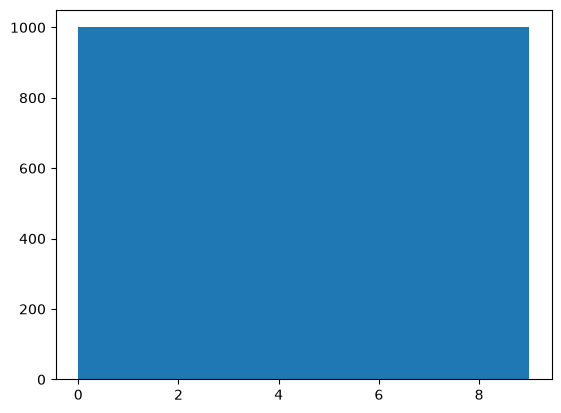

In [38]:
plt.hist(test_dataset.targets)

(array([6000., 6000., 6000., 6000., 6000., 6000., 6000., 6000., 6000.,
        6000.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

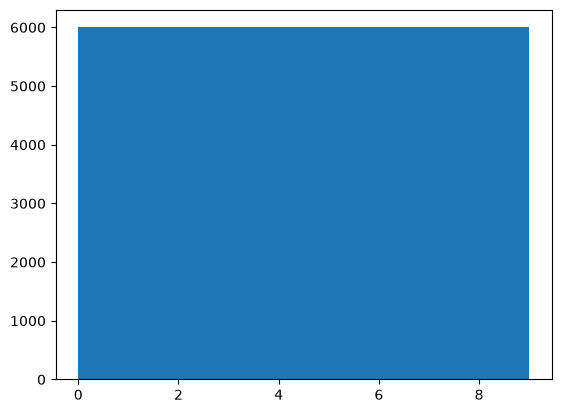

In [39]:
plt.hist(train_dataset.targets)

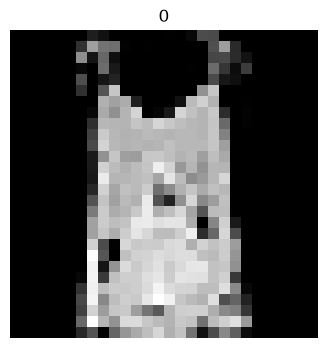

In [40]:
image, label = train_dataset[67]

# Если Tensor: [1, 28, 28] → [28, 28]
image = image.squeeze().numpy()

fig, ax = plt.subplots(figsize=(4, 4))

for i in range(28):
    for j in range(28):
        pixel = image[i, j]

        square = Rectangle(
            (j, 27 - i),  # x, y
            1,  # ширина
            1,  # высота
            facecolor=str(pixel),
        )

        ax.add_patch(square)

ax.set_xlim(0, 28)
ax.set_ylim(0, 28)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(label)

plt.show()

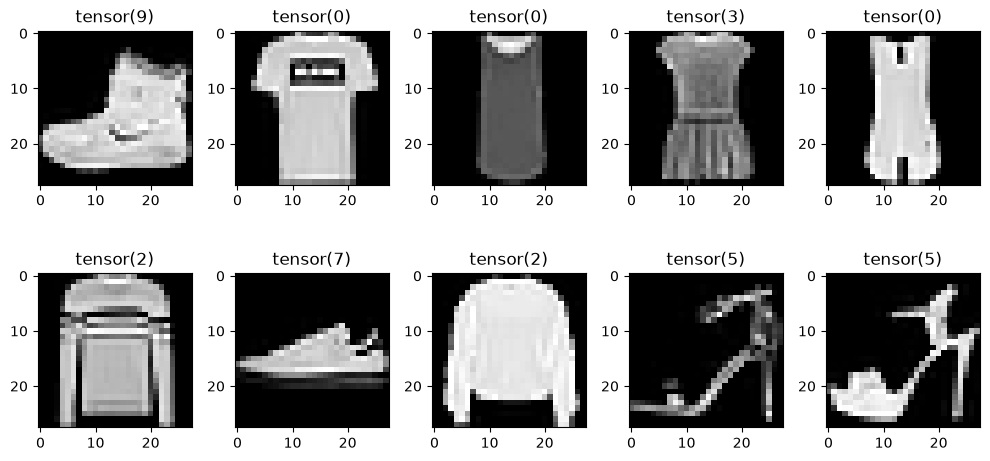

In [41]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_dataset.data[i], cmap="gray")
    plt.title(train_dataset.targets[i])
plt.tight_layout()
plt.show()

In [42]:
x_batch, y_batch = next(iter(train_loader))
x_batch.shape, y_batch.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [43]:
x_batch.reshape(x_batch.shape[0], -1).shape  # flatten(start_dim=1)

torch.Size([128, 784])

# Modeling

In [44]:
results = []


def save_result(model_name, train_accuracy, test_accuracy):
    results.append(
        {
            "model": model_name,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        }
    )

### Simple MLP model

In [45]:
simple_model = nn.Sequential(
    nn.Linear(features, 128),
    nn.ReLU(),
    nn.Linear(128, classes),
)
criterion = nn.CrossEntropyLoss()
karpathys_constant = 3e-4
optimizer = torch.optim.AdamW(
    simple_model.parameters(), lr=karpathys_constant, betas=(0.9, 0.99)
)
simple_model.to(device)

best_val_loss = float("inf")
patience = 3
epochs = 50
history = []
history_val = []
for i in range(epochs):
    simple_model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.reshape(x_batch.shape[0], -1).to(device)
        y_batch = y_batch.to(device)

        logits = simple_model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    simple_model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.reshape(x_batch.shape[0], -1).to(device)
            y_batch = y_batch.to(device)

            logits = simple_model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(simple_model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
simple_model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.789728695947031 , val_loss - 0.5531556447769733
epoch - 1,train_loss - 0.49707946896269883 , val_loss - 0.4817284047603607
epoch - 2,train_loss - 0.4480327846318696 , val_loss - 0.46548572182655334
epoch - 3,train_loss - 0.4232279060501384 , val_loss - 0.4433537055837347
epoch - 4,train_loss - 0.4035985732446657 , val_loss - 0.4209288973757561
epoch - 5,train_loss - 0.38856865741719543 , val_loss - 0.40109482978252653
epoch - 6,train_loss - 0.37687640100929914 , val_loss - 0.3944055501450884
epoch - 7,train_loss - 0.3663866352865079 , val_loss - 0.39590112960084956
epoch - 8,train_loss - 0.35951028325353834 , val_loss - 0.3838895514924475
epoch - 9,train_loss - 0.35051028072975593 , val_loss - 0.3790584647275032
epoch - 10,train_loss - 0.3415623128130997 , val_loss - 0.3707198792315544
epoch - 11,train_loss - 0.33566968865037816 , val_loss - 0.36344810147234735
epoch - 12,train_loss - 0.3300408660799194 , val_loss - 0.3659119041676217
epoch - 13,train_loss - 0.

<All keys matched successfully>

In [46]:
simple_model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.reshape(x_batch.shape[0], features).to(device)
        y_batch = y_batch.to(device)

        logits = simple_model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.reshape(x_batch.shape[0], features).to(device)
        y_batch = y_batch.to(device)

        logits = simple_model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy: {test_accuracy.item():.4f}")
save_result(
    model_name="Simple MLP",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9105
Accuracy: 0.8793


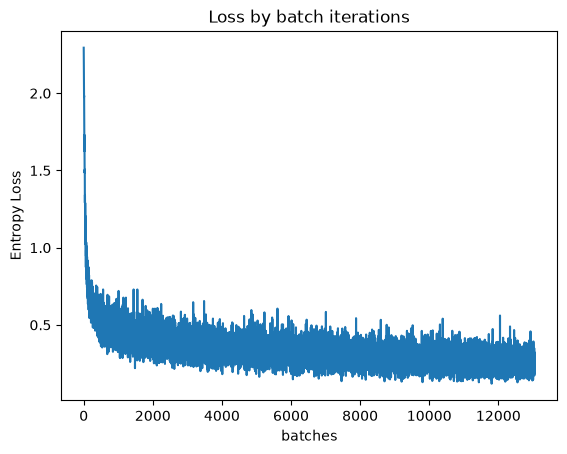

In [47]:
plt.plot(history)
plt.title("Loss by batch iterations")
plt.ylabel("Entropy Loss")
plt.xlabel("batches")

plt.show()

###  Tunning MLP model

In [48]:
features = 28 * 28
classes = 10
simple_model = nn.Sequential(
    nn.Linear(features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, classes),
)
criterion = nn.CrossEntropyLoss()
karpathys_constant = 3e-4
optimizer = torch.optim.AdamW(
    simple_model.parameters(), lr=karpathys_constant, betas=(0.9, 0.99)
)
simple_model.to(device)

best_val_loss = float("inf")
patience = 7
epochs = 100
history = []
history_val = []
for i in range(epochs):
    simple_model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.reshape(x_batch.shape[0], -1).to(device)
        y_batch = y_batch.to(device)

        logits = simple_model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    simple_model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.reshape(x_batch.shape[0], -1).to(device)
            y_batch = y_batch.to(device)

            logits = simple_model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(simple_model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
simple_model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.5983049012986045 , val_loss - 0.3780776896375291
epoch - 1,train_loss - 0.37728833861985284 , val_loss - 0.34108976575922456
epoch - 2,train_loss - 0.3408345472501179 , val_loss - 0.3288970389898787
epoch - 3,train_loss - 0.312036939974069 , val_loss - 0.34230636757739047
epoch - 4,train_loss - 0.2960980661974384 , val_loss - 0.32480059595818217
epoch - 5,train_loss - 0.28009568200824947 , val_loss - 0.3082051632252145
epoch - 6,train_loss - 0.2671100101533242 , val_loss - 0.3077364700271728
epoch - 7,train_loss - 0.25505555897172444 , val_loss - 0.29464107307981935
epoch - 8,train_loss - 0.24311665741111774 , val_loss - 0.28873023327360764
epoch - 9,train_loss - 0.23224972011499337 , val_loss - 0.314082829559103
epoch - 10,train_loss - 0.22210146364647532 , val_loss - 0.2987656092390101
epoch - 11,train_loss - 0.21782647021946602 , val_loss - 0.30359770547836384
epoch - 12,train_loss - 0.20879479156112443 , val_loss - 0.3887071279769248
epoch - 13,train_loss -

<All keys matched successfully>

In [49]:
simple_model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.reshape(x_batch.shape[0], features).to(device)
        y_batch = y_batch.to(device)

        logits = simple_model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.reshape(x_batch.shape[0], features).to(device)
        y_batch = y_batch.to(device)

        logits = simple_model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy: {test_accuracy.item():.4f}")
save_result(
    model_name="Tunned MLP",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9314
Accuracy: 0.8877


In [50]:
results

[{'model': 'Simple MLP',
  'train_accuracy': tensor(0.9105, device='cuda:0'),
  'test_accuracy': tensor(0.8793, device='cuda:0')},
 {'model': 'Tunned MLP',
  'train_accuracy': tensor(0.9314, device='cuda:0'),
  'test_accuracy': tensor(0.8877, device='cuda:0')}]

### Alexnet

In [51]:
model = alexnet(num_classes=10)

# Меняем первый слой под 1 канал вместо 3
model.features[0] = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1,
)

# Меняем classifier под FashionMNIST
model.classifier[6] = nn.Linear(4096, 10)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
karpathys_constant = 3e-4
optimizer = torch.optim.AdamW(
    model.parameters(), lr=karpathys_constant, betas=(0.9, 0.99)
)
model.to(device)

best_val_loss = float("inf")
patience = 7
epochs = 100
history = []
history_val = []
for i in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.6692176288847685 , val_loss - 0.42388961923883317
epoch - 1,train_loss - 0.36086881323551623 , val_loss - 0.3558573025338193
epoch - 2,train_loss - 0.2975202862553812 , val_loss - 0.2966320299087687
epoch - 3,train_loss - 0.2619005064712284 , val_loss - 0.26294733060801284
epoch - 4,train_loss - 0.23867501306066605 , val_loss - 0.25091017846097335
epoch - 5,train_loss - 0.21529101665328632 , val_loss - 0.26764789509012343
epoch - 6,train_loss - 0.19888058711825526 , val_loss - 0.2327118455729586
epoch - 7,train_loss - 0.18378657128245984 , val_loss - 0.22996968205304855
epoch - 8,train_loss - 0.167265131954555 , val_loss - 0.2152325599751574
epoch - 9,train_loss - 0.15293343819129213 , val_loss - 0.2274966813782428
epoch - 10,train_loss - 0.14109011475802033 , val_loss - 0.23649655805623276
epoch - 11,train_loss - 0.12706620830184207 , val_loss - 0.24678150231533863
epoch - 12,train_loss - 0.11892172884895089 , val_loss - 0.2632187023124796
epoch - 13,train_los

<All keys matched successfully>

In [52]:
model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy test: {test_accuracy.item():.4f}")
save_result(
    model_name="Alexnet AS IS",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9524
Accuracy test: 0.9186


### Resnet

In [53]:
model = resnet18(weights=None)

model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

model.maxpool = nn.Identity()

model.fc = nn.Linear(model.fc.in_features, classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
karpathys_constant = 3e-4
optimizer = torch.optim.AdamW(
    model.parameters(), lr=karpathys_constant, betas=(0.9, 0.99)
)
model.to(device)

best_val_loss = float("inf")
patience = 7
epochs = 100
history = []
history_val = []
for i in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.38047198455718806 , val_loss - 0.3546885435885571
epoch - 1,train_loss - 0.227518176664366 , val_loss - 0.2530664668438282
epoch - 2,train_loss - 0.16889069337318174 , val_loss - 0.22760966245798356
epoch - 3,train_loss - 0.12391577138965883 , val_loss - 0.22860058349497775
epoch - 4,train_loss - 0.08998636961549591 , val_loss - 0.24734251518198785
epoch - 5,train_loss - 0.06850753440532718 , val_loss - 0.25979951975193427
epoch - 6,train_loss - 0.054292438153593386 , val_loss - 0.28552045181710667
epoch - 7,train_loss - 0.044916420845390076 , val_loss - 0.3072288863836451
epoch - 8,train_loss - 0.038514934881145664 , val_loss - 0.3649466448324792
epoch - 9,train_loss - 0.03449271947384376 , val_loss - 0.3484213943494127
Early stopping!


<All keys matched successfully>

In [54]:
model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy test: {test_accuracy.item():.4f}")
save_result(
    model_name="RESNET AS IS",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9573
Accuracy test: 0.9131


### Tunned Resnet 
weight_decay=0.05 + dropout in fc + lr = 3e-3

In [55]:
model = resnet18(weights=None)

model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

model.maxpool = nn.Identity()

model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, classes))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
lr = 3e-3
optimizer = torch.optim.AdamW(
    model.parameters(), lr=lr, betas=(0.9, 0.99), weight_decay=0.05
)
model.to(device)

best_val_loss = float("inf")
patience = 7
epochs = 100
history = []
history_val = []
for i in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.4537366234704038 , val_loss - 0.33814228595571316
epoch - 1,train_loss - 0.283033322888004 , val_loss - 0.2586713113049243
epoch - 2,train_loss - 0.23778818791948986 , val_loss - 0.3185378094302847
epoch - 3,train_loss - 0.2037489234587076 , val_loss - 0.23348615905071826
epoch - 4,train_loss - 0.17226176095723822 , val_loss - 0.19269186099793048
epoch - 5,train_loss - 0.14639995534707417 , val_loss - 0.20933584203111363
epoch - 6,train_loss - 0.12283420458772262 , val_loss - 0.20498843491077423
epoch - 7,train_loss - 0.10342579612822544 , val_loss - 0.24124577403702635
epoch - 8,train_loss - 0.0864200051962409 , val_loss - 0.21975840295248844
epoch - 9,train_loss - 0.07447920262707385 , val_loss - 0.23849418759346008
epoch - 10,train_loss - 0.061625097761032414 , val_loss - 0.2350540595485809
epoch - 11,train_loss - 0.055399038217245046 , val_loss - 0.2390857294518897
Early stopping!


<All keys matched successfully>

In [56]:
model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy test: {test_accuracy.item():.4f}")
save_result(
    model_name="RESNET tunned",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9512
Accuracy test: 0.9232


### Swin transformer

In [57]:
model = swin_t(weights=None)

# 1 канал вместо 3
model.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4)

# 10 классов вместо 1000
model.head = nn.Linear(model.head.in_features, classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
karpathys_constant = 3e-4
optimizer = torch.optim.AdamW(
    model.parameters(), lr=karpathys_constant, betas=(0.9, 0.99)
)
model.to(device)

best_val_loss = float("inf")
patience = 7
epochs = 100
history = []
history_val = []
for i in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.5560642823116796 , val_loss - 0.40973091632761854
epoch - 1,train_loss - 0.38287350390274566 , val_loss - 0.3640326718066601
epoch - 2,train_loss - 0.3381103217035461 , val_loss - 0.3281582492463132
epoch - 3,train_loss - 0.31057585418365913 , val_loss - 0.3570966048443571
epoch - 4,train_loss - 0.2846547938936397 , val_loss - 0.2989700528535437
epoch - 5,train_loss - 0.26438636868979754 , val_loss - 0.2943724463594721
epoch - 6,train_loss - 0.24844473175651388 , val_loss - 0.2803558792839659
epoch - 7,train_loss - 0.2301006509331796 , val_loss - 0.27198883447241273
epoch - 8,train_loss - 0.21527584105942424 , val_loss - 0.2827207154416023
epoch - 9,train_loss - 0.19756721039778263 , val_loss - 0.2829157348642958
epoch - 10,train_loss - 0.19170540652620538 , val_loss - 0.27562912062127537
epoch - 11,train_loss - 0.1781102827531142 , val_loss - 0.2858892882123907
epoch - 12,train_loss - 0.17088488815020494 , val_loss - 0.2708744099165531
epoch - 13,train_loss - 

<All keys matched successfully>

In [58]:
model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy test: {test_accuracy.item():.4f}")
save_result(
    model_name="SWIN transformer",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9591
Accuracy test: 0.9096


### Swin transformer finetuned

In [59]:
model = swin_t(weights=Swin_T_Weights.DEFAULT)

# 1 канал вместо 3
model.features[0][0] = nn.Conv2d(
    in_channels=1, out_channels=96, kernel_size=4, stride=4
)

# 1000 классов → 10
model.head = nn.Linear(model.head.in_features, classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
karpathys_constant = 3e-4
optimizer = torch.optim.AdamW(
    model.parameters(), lr=karpathys_constant, betas=(0.9, 0.99)
)
model.to(device)

best_val_loss = float("inf")
patience = 7
epochs = 100
history = []
history_val = []
for i in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)

        loss = criterion(logits, y_batch)
        history.append(loss.item())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            loss = criterion(logits, y_batch)
            history_val.append(loss.item())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"epoch - {i},train_loss - {train_loss} , val_loss - {val_loss}")
    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        best_model_state = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

# Загружаем лучшие веса
model.load_state_dict(best_model_state)

epoch - 0,train_loss - 0.5112587143080818 , val_loss - 0.3302192687988281
epoch - 1,train_loss - 0.3061256003422295 , val_loss - 0.26601756887233
epoch - 2,train_loss - 0.25286368710694573 , val_loss - 0.2799919973662559
epoch - 3,train_loss - 0.21339316409514805 , val_loss - 0.2521765401705782
epoch - 4,train_loss - 0.1811087600479783 , val_loss - 0.24010521902682933
epoch - 5,train_loss - 0.1530556149709961 , val_loss - 0.26659568985725973
epoch - 6,train_loss - 0.13428781232896156 , val_loss - 0.257836399718802
epoch - 7,train_loss - 0.11554345585441221 , val_loss - 0.2732501412008671
epoch - 8,train_loss - 0.0977755097048512 , val_loss - 0.2763647166021327
epoch - 9,train_loss - 0.08867328562453 , val_loss - 0.28670795927656456
epoch - 10,train_loss - 0.07595144751793627 , val_loss - 0.33985633307949026
epoch - 11,train_loss - 0.07019960107901212 , val_loss - 0.3014980224852866
Early stopping!


<All keys matched successfully>

In [60]:
model.eval()

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

train_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy train: {train_accuracy.item():.4f}")

predictions = []
y_test = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        predictions.append(preds)
        y_test.append(y_batch)

predictions = torch.cat(predictions)
y_test = torch.cat(y_test)

test_accuracy = (predictions == y_test).float().mean()

print(f"Accuracy test: {test_accuracy.item():.4f}")
save_result(
    model_name="SWIN transformer finetuned",
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy,
)

Accuracy train: 0.9537
Accuracy test: 0.9087


# Results and conclusuions
1. Использования сверточных сетей для CV задачи и этого датасета дало прирост по точности 3.5% с 88.77% до 92.32%.
2. Каждое зменение гиперпараметров нейроситей давали хоть и небольшой но прирост. В одном случае с 91.31% до 92.32%, в другом 87.93% до 88.77%. Да улучшение незначитальные, но они были подобраны в ручную, думаю при помощи более продвинутых методов подробора можно было бы получить больший прирост.
3. Трансформер отработал хуже, чем более старый RESNET, даже файнтюнинг с инизиализацией весов не повысил качество. Говорит о том, что под конкретную задачу важна более детальная настройка модели и её архитектуры, а не просто взять самую новую модель. 
4. Применяемые модели не предназначены для размера картинки 28х28, из-за размеров яред, карт активаций, пуллингов в их свертках, поэтому не было сильного прироста качества.
5. В идеале под эту задачу нужно подобрать архитектуры свертки для 28х28. Либо как вариант масштабировать картинку до больших размеров подходящих для Alexnet и других моделей.
6. Даже базовая MLP справилась хорошо, значит данные достаточно чистые и даже слабенькая сеть может уловить закономерность.


In [61]:
results_df = (
    pd.DataFrame(results)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)

results_df.style.format(
    {
        "train_accuracy": "{:.2%}",
        "test_accuracy": "{:.2%}",
    }
)

,model,train_accuracy,test_accuracy
0,RESNET tunned,95.12%,92.32%
1,Alexnet AS IS,95.24%,91.86%
2,RESNET AS IS,95.73%,91.31%
3,SWIN transformer,95.91%,90.96%
4,SWIN transformer finetuned,95.37%,90.87%
5,Tunned MLP,93.14%,88.77%
6,Simple MLP,91.05%,87.93%
